Trajectory stats:
	max vel_mag: 3.96 m/s
	max acc_mag: 1.24 m/s^2
	max yaw_rate: 116.88 deg/s


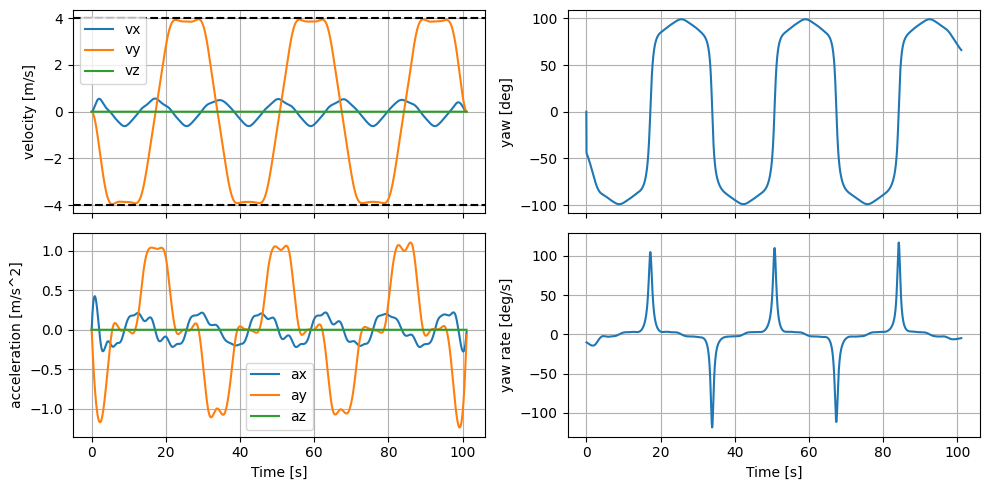

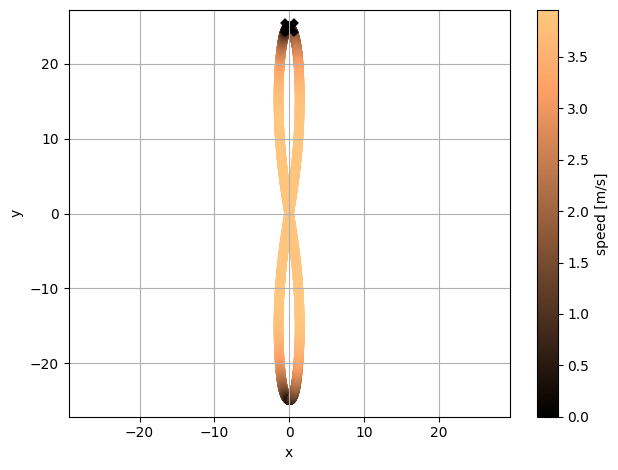

In [23]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%matplotlib inline

df = pd.read_csv(
    "/home/morten/workspaces/noetic_ws/src/large_scale_traj_optimizer/min_snap_traj_gen/trajectory.csv"
)

vmax = 4.0

fig, ax = plt.subplots(nrows=2, ncols=2, sharex=True, figsize=(10,5))
df.plot(ax=ax[0,0], x="time", y=["vx", "vy", "vz"])
ax[0,0].axhline(-vmax, color='k', ls='--')
ax[0,0].axhline(vmax, color='k', ls='--')
df.plot(ax=ax[1,0], x="time", y=["ax", "ay", "az"])
ax[0,1].plot(df["time"], np.degrees(df["yaw"]))
ax[1,1].plot(df["time"], np.degrees(df["yaw_rate"]))
for a in ax.flatten():
    a.grid()
for a in ax[-1,:]:
    a.set_xlabel('Time [s]')
ax[0,0].set_ylabel('velocity [m/s]')
ax[1,0].set_ylabel('acceleration [m/s^2]')
ax[0,1].set_ylabel('yaw [deg]')
ax[1,1].set_ylabel('yaw rate [deg/s]')
fig.tight_layout()

vel_mag = np.linalg.norm(df[["vx", "vy", "vz"]], axis=1)
acc_mag = np.linalg.norm(df[['ax','ay','az']], axis=1)

max_vel = np.max(vel_mag)
max_acc = np.max(acc_mag)
max_yaw_rate = np.degrees(np.max(df["yaw_rate"]))
print(f"Trajectory stats:\n\tmax vel_mag: {max_vel:0.2f} m/s\n\tmax acc_mag: {max_acc:0.2f} m/s^2\n\tmax yaw_rate: {max_yaw_rate:0.2f} deg/s")

fig, ax = plt.subplots()
sc = ax.scatter(df["px"], df["py"], c=vel_mag, cmap='copper')
ax.scatter([df["px"].iloc[0]], [df["py"].iloc[0]], s=100, c="k", marker="x", lw=5)
ax.grid()
ax.axis("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
fig.colorbar(sc, label='speed [m/s]')
fig.tight_layout()